# LeetCode #157: Read N Characters Given Read4

https://leetcode.com/problems/read-n-characters-given-read4/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Iterative with Read4** | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Iterative with Read4 ★
Use a temporary buffer of size 4. Repeatedly call `read4(buf4)` which reads up to 4 characters from a file into `buf4` and returns how many were actually read. Copy characters from `buf4` into the destination buffer `buf` until either:
1. We have read `n` characters total, or
2. `read4` returns fewer than 4 (end of file reached).

**Why this is straightforward:** There is only one approach — the API constrains us to read in chunks of 4. We just need to be careful about the boundary: the last chunk may have more characters than we need, so we only copy `min(charsRead, n - totalRead)`.

**Constraints:**
* This method is called only once per file.
* `1 <= n` — we always want at least one character.

## Solutions

### C#

In [ ]:
// The Read4 API is defined in the parent class Reader4.
// int Read4(char[] buf4);

public class Solution : Reader4 {
    public int Read(char[] buf, int n) {
        char[] buf4 = new char[4];
        int total = 0;
        
        while (total < n) {
            int count = Read4(buf4);
            int toCopy = Math.Min(count, n - total);
            for (int i = 0; i < toCopy; i++) {
                buf[total++] = buf4[i];
            }
            if (count < 4) break;
        }
        
        return total;
    }
}

### Python

In [ ]:
class Solution:
    def read(self, buf, n):
        """
        :type buf: Destination buffer (List[str])
        :type n: Number of characters to read (int)
        :rtype: The number of actual characters read (int)
        """
        buf4 = [''] * 4
        total = 0
        
        while total < n:
            count = read4(buf4)
            to_copy = min(count, n - total)
            for i in range(to_copy):
                buf[total] = buf4[i]
                total += 1
            if count < 4:
                break
        
        return total

### Go

In [ ]:
// The read4 API is already defined for you.
// var read4 = func(buf4 []byte) int

var solution = func(read4 func([]byte) int) func([]byte, int) int {
    return func(buf []byte, n int) int {
        buf4 := make([]byte, 4)
        total := 0
        
        for total < n {
            count := read4(buf4)
            toCopy := count
            if n-total < toCopy {
                toCopy = n - total
            }
            copy(buf[total:], buf4[:toCopy])
            total += toCopy
            if count < 4 {
                break
            }
        }
        
        return total
    }
}

### Rust

In [ ]:
impl Solution {
    pub fn read(&self, buf: &mut [char], n: i32) -> i32 {
        let n = n as usize;
        let mut buf4 = [' '; 4];
        let mut total = 0;
        
        while total < n {
            let count = read4(&mut buf4) as usize;
            let to_copy = count.min(n - total);
            for i in 0..to_copy {
                buf[total] = buf4[i];
                total += 1;
            }
            if count < 4 {
                break;
            }
        }
        
        total as i32
    }
}

## Example Scenarios

### 1. Common Case
**Input:** file = `"abcdefgh"`, $n = 5$  
First read4 fills buf4 with $[a,b,c,d]$, returns 4. Copy all 4 (total=4). Second read4 returns $[e,f,g,h]$, but we only need $\min(4, 5-4) = 1$. Copy only 'e'. Stop.  
WHY tricky: Second read4 returns 4 chars but we only need 1. The guard $\min(\text{count}, n - \text{total})$ prevents buffer overrun past the requested $n$.  
**Output:** `5` — buf = `"abcde"`

### 2. Slightly Complex
**Input:** file = `"abcde"`, $n = 7$  
First read4 returns 4, copy all (total=4). Second read4 returns 1 ($< 4 \Rightarrow$ EOF). Copy 1 (total=5). Break. Return 5, not 7.  
WHY tricky: $n$ exceeds file length. Must detect EOF via $\text{read4} < 4$ and stop early. Returning total (5), not $n$ (7), is correct behavior.  
**Output:** `5` — file exhausted before $n$ reached

### 3. Edge Case: Time Factor
**Input:** file = 100,000 characters, $n = 100{,}000$  
Need $\lceil 100{,}000 / 4 \rceil = 25{,}000$ calls to read4. Each call reads exactly 4 chars (except possibly the last). Total: $O(n)$.  
WHY tricky: Each read4 is $O(1)$, called $O(n/4)$ times. No way to read fewer than $\lceil n/4 \rceil$ chunks since read4 is the only API.  
**Output:** `100,000` — optimal $O(n)$ time

### 4. Edge Case: Space Factor
**Input:** file = `"abcd"`, $n = 4$ (exact multiple of 4)  
First read4 returns 4, copy all (total=4). Now $\text{total} = n$, loop exits on condition $\text{total} < n$ being false. Only $O(1)$ extra space: the 4-byte buf4 buffer.  
WHY tricky: When $n$ is an exact multiple of 4, the loop exits on $\text{total} = n$, NOT on EOF detection. The algorithm does not need an extra read4 to confirm EOF.  
**Output:** `4` — exact fit, $O(1)$ extra space

### 5. Almost-Impossible but Plausible
**Input:** file = `""` (empty), $n = 1$  
First read4 returns 0 — empty file. $\text{toCopy} = \min(0, 1-0) = 0$. Since $0 < 4$, detect EOF and break. Return 0.  
WHY tricky: Empty file returns 0 from read4 on the very first call. The $\text{count} < 4$ check handles both 'partial last chunk' and 'completely empty file' uniformly.  
**Output:** `0` — empty file, nothing read

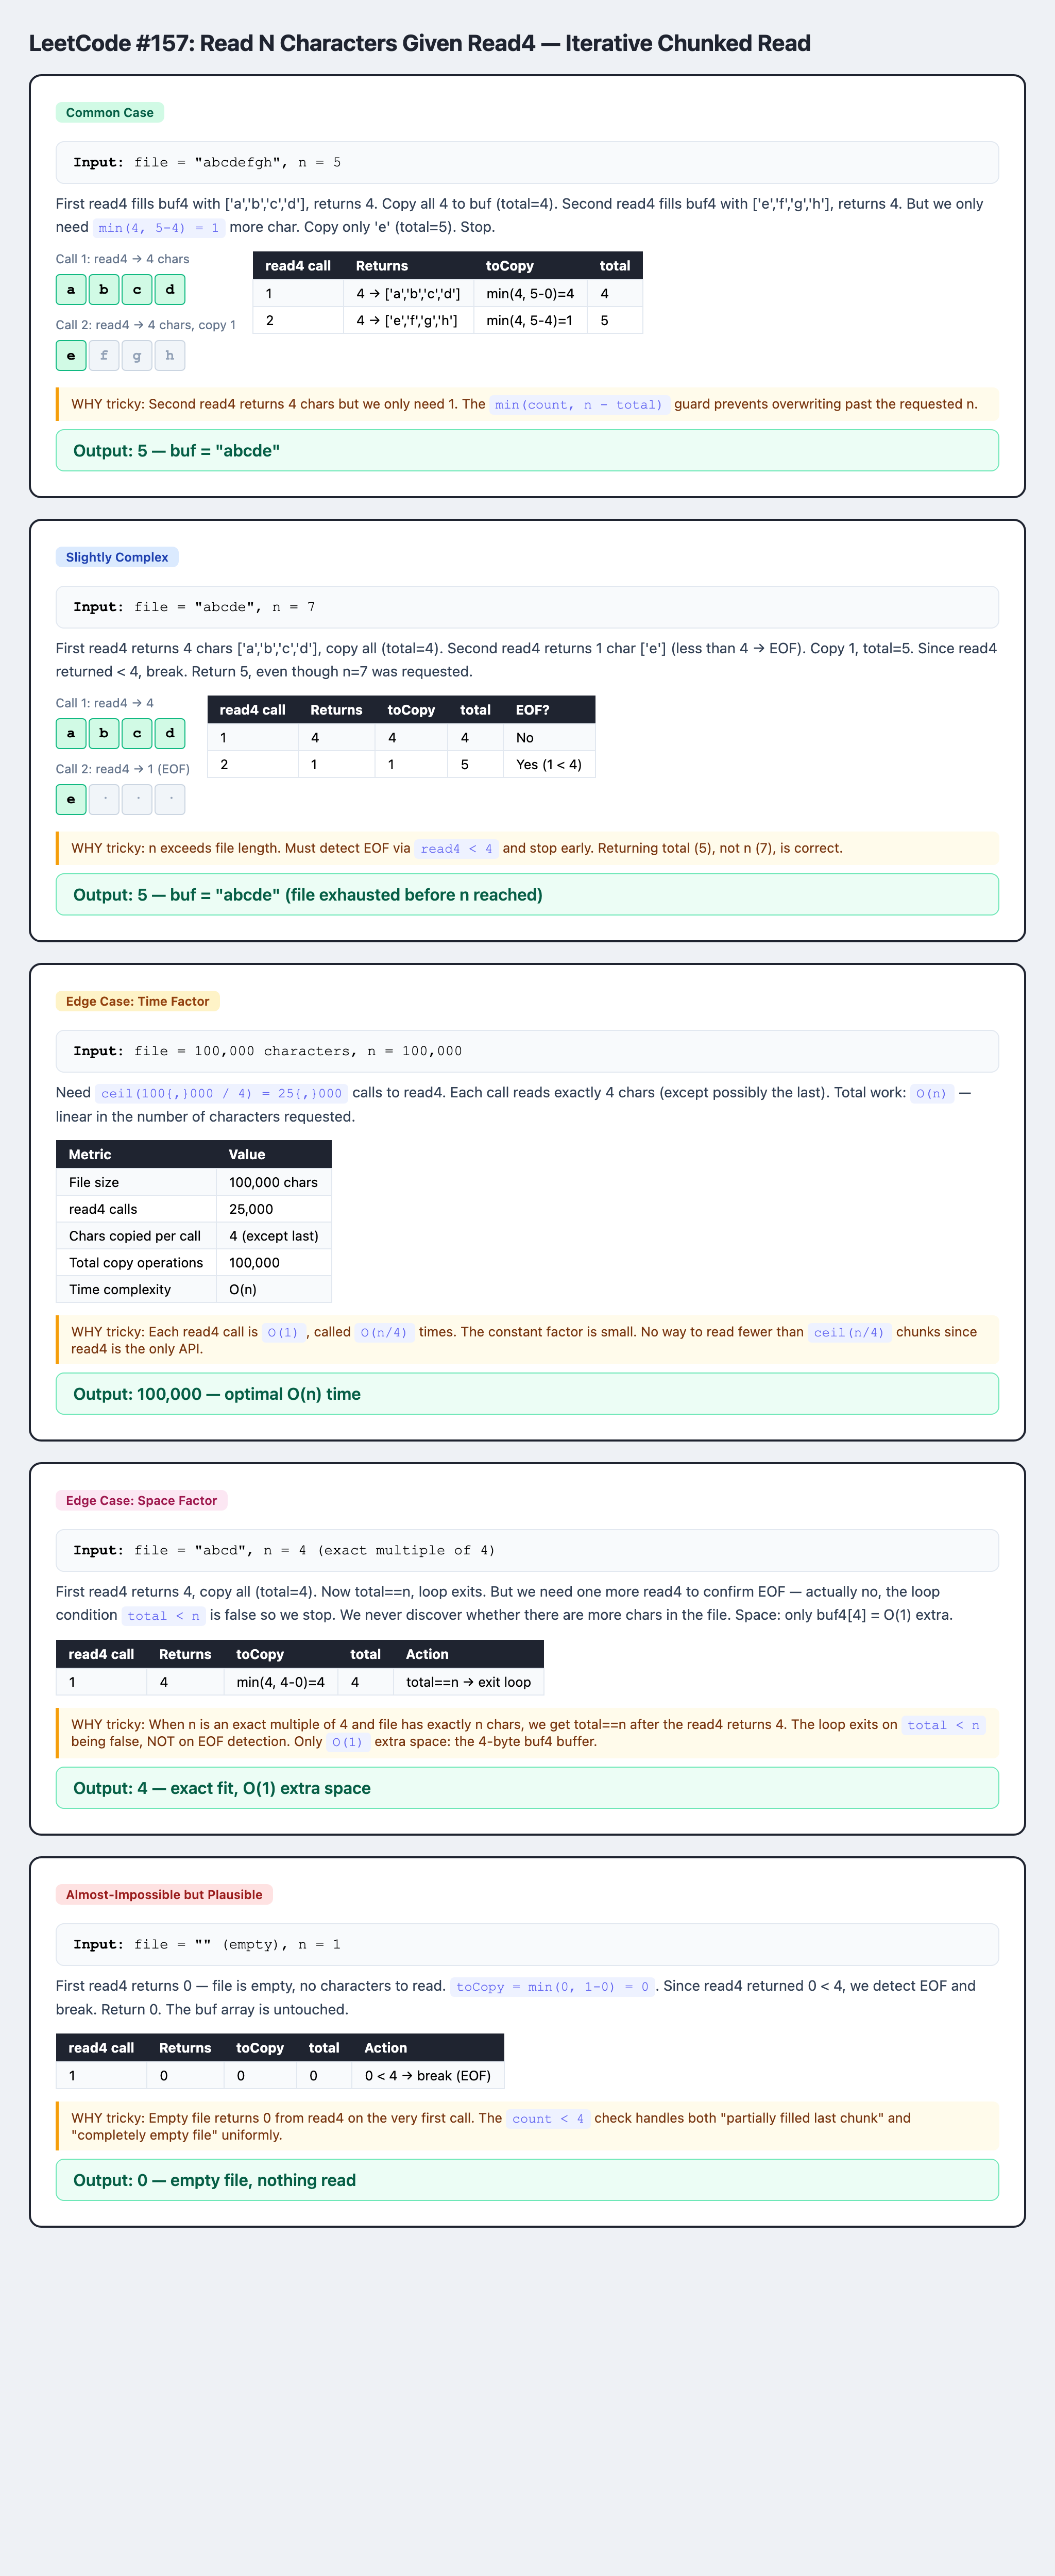